# Week 5 Lab: Attention, then a small text generator

**Module:** Generative AI (MSc in Artificial Intelligence)
**Time:** 2 hours. **Learning outcomes:** MIMLO 1, 3.

You will build one useful operation at a time:

1. Mix information with **attention**, and check your calculation.
2. Hide future characters with a **causal mask**.
3. Combine attention heads in a **transformer block**.
4. Train a small model to predict the next character.
5. Inspect two pretrained models, BERT and GPT-2.
6. Optionally measure generation with and without a **key/value cache**.

**Runtime:** the complete GPU experiment trains for 3,000 updates.
The CPU route uses a smaller model, shorter sequences and 200 updates.
These settings teach the same operations; their results are not comparable.
Runtime and output quality depend on your machine and settings.
A smoke run checks execution with very small settings; it does not measure
the quality of a trained language model.

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **GPU** if available. A T4 is sufficient for the GPU examples. Free GPU access varies. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. Read this week's runtime note. Model downloads and training can take longer on CPU, and some full experiments need a GPU.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete before running dependent cells. Questions marked ✍️ need a short written answer.
> - Read each diagram by following its numbered blocks. The solid arrows carry data to the next block. A dashed arrow shows a step that repeats.

## This week's place in the course

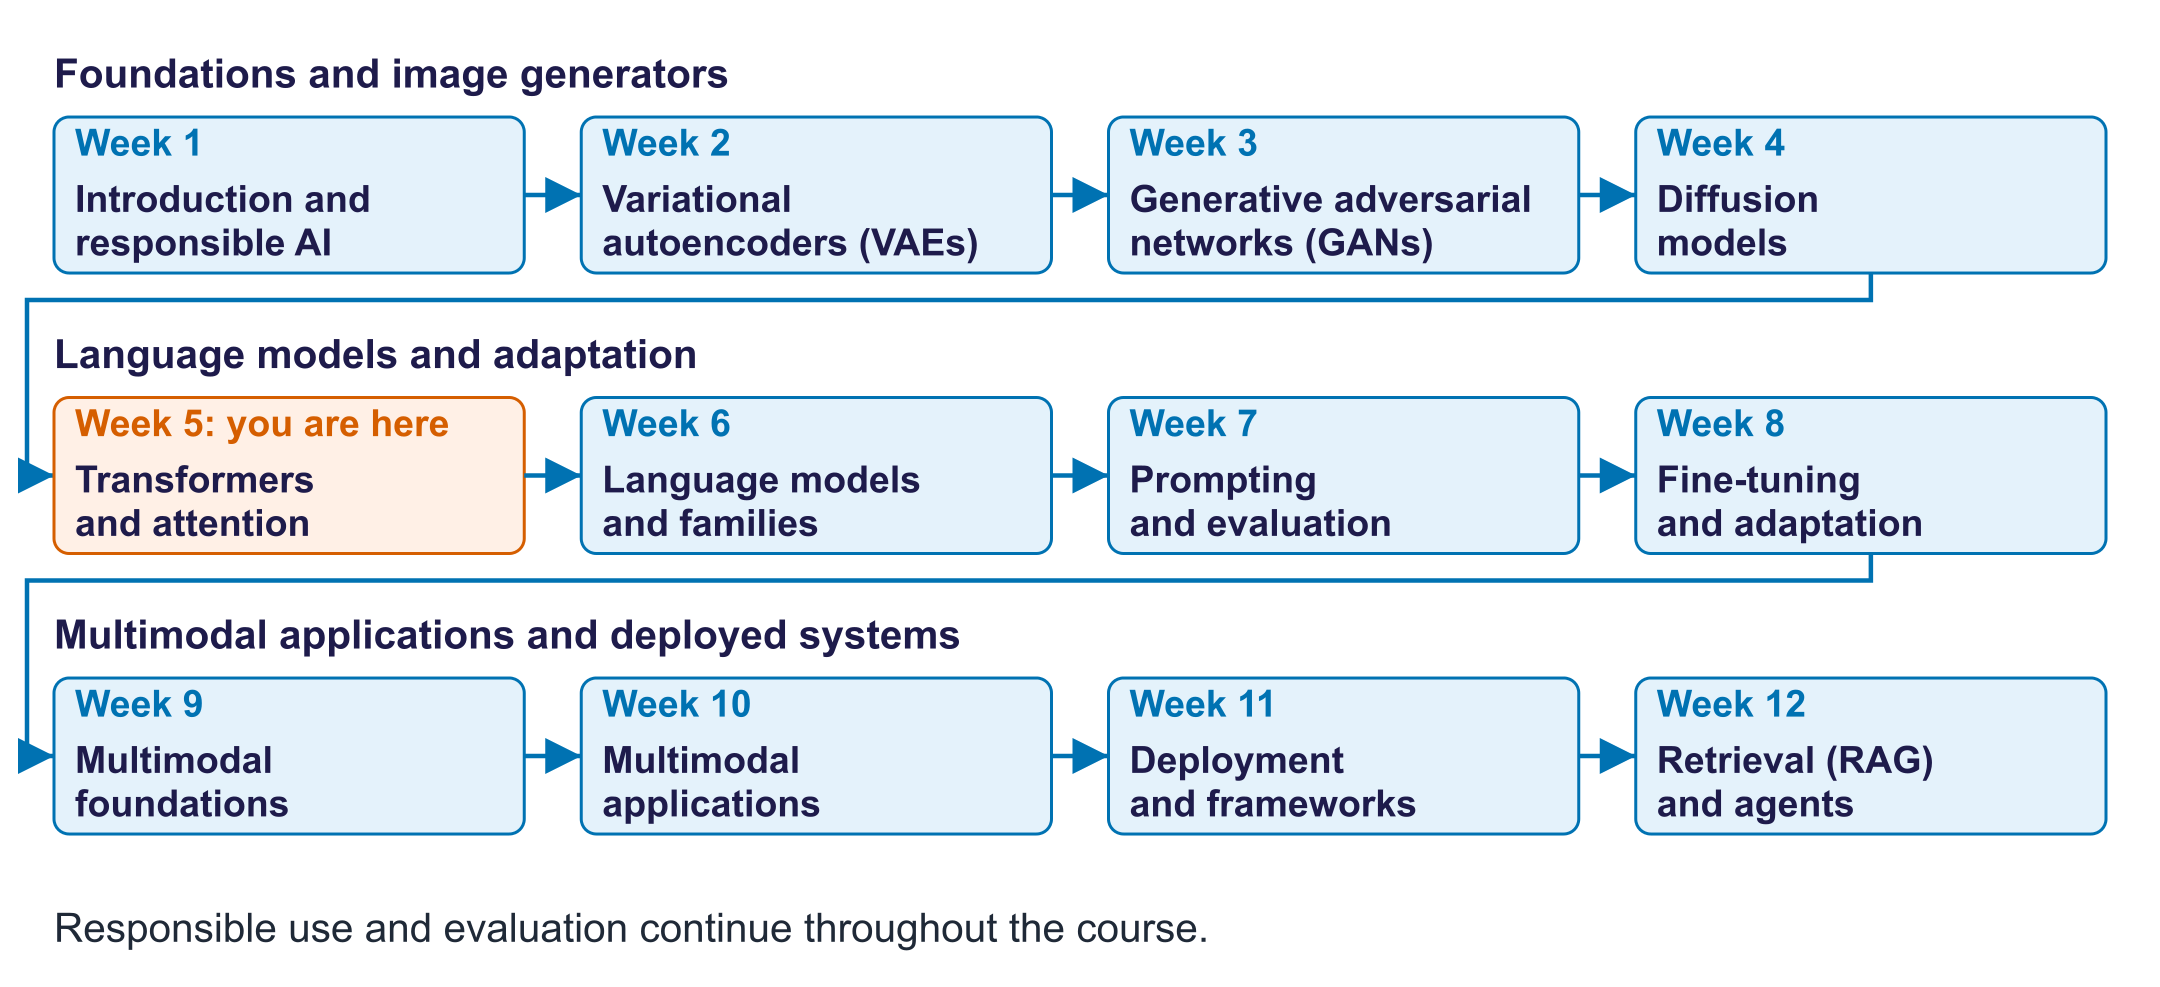

## Start here: follow one character through the system

Our small model reads **characters**, rather than words or word pieces.
`ROME` supplies the inputs; `OMEO` supplies the next-character targets.
A **token** is one unit the model reads: one character in this experiment.
An **embedding** is the learned list of numbers assigned to a token.
A **tensor** is a numerical array with named axes, such as batch and position.

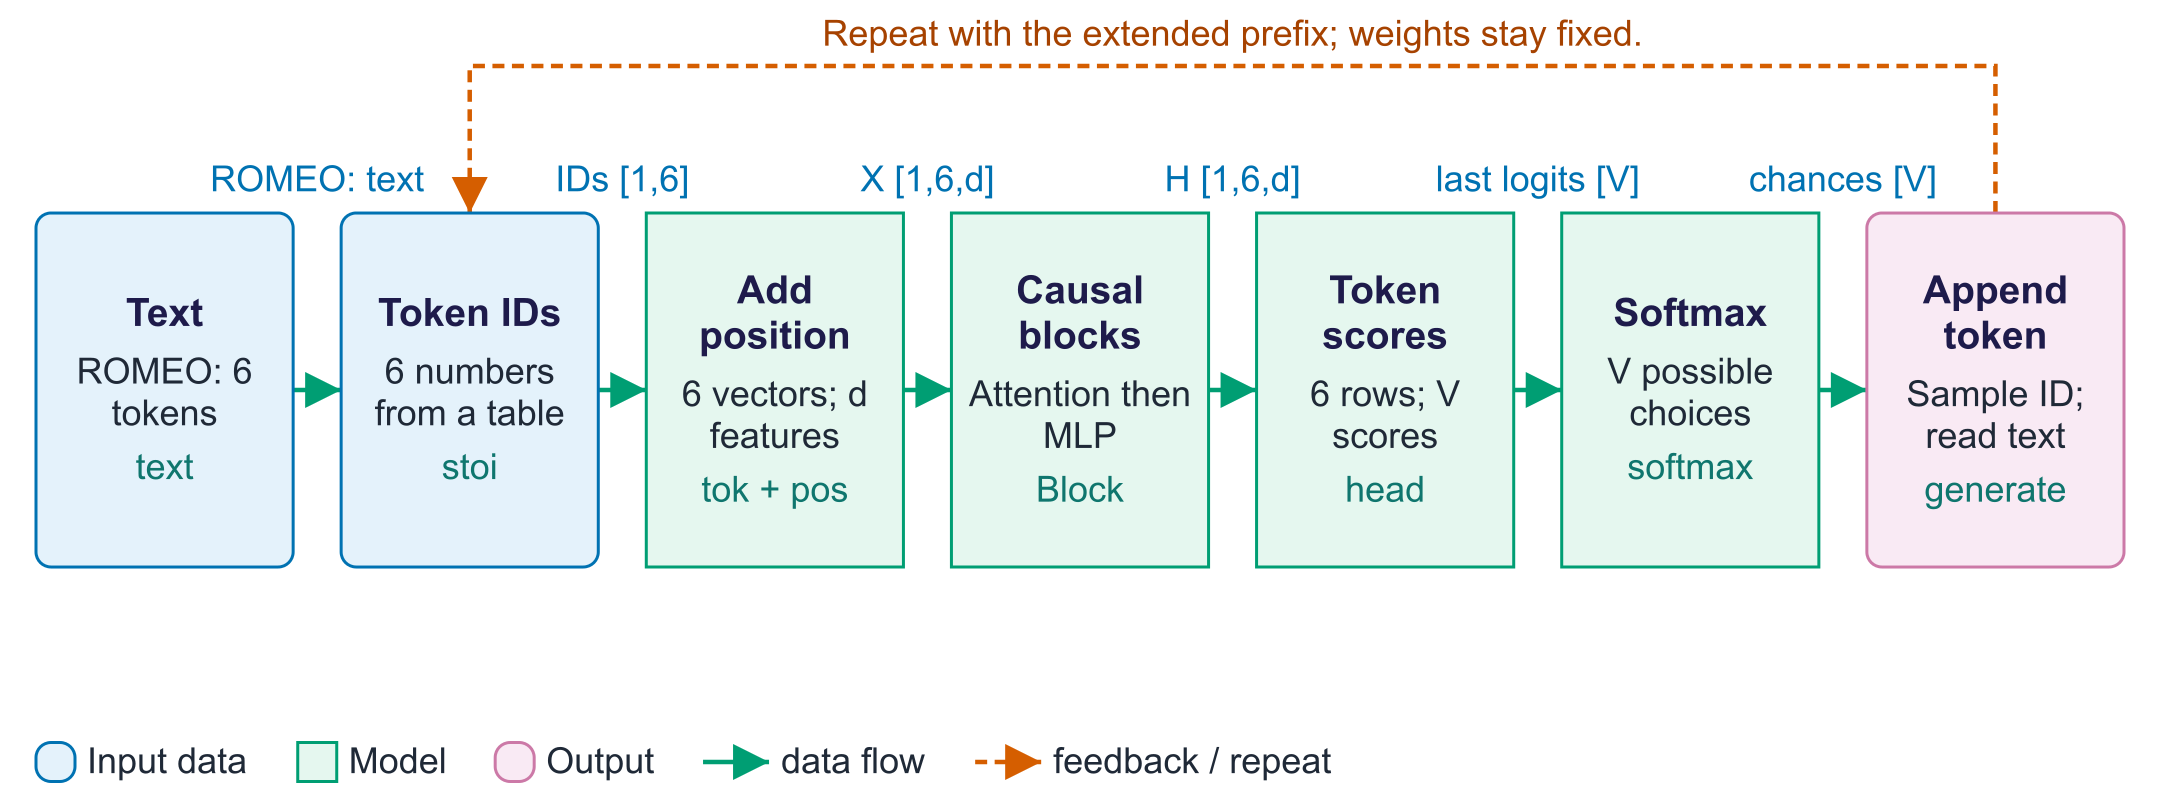

## Find each diagram block in the notebook

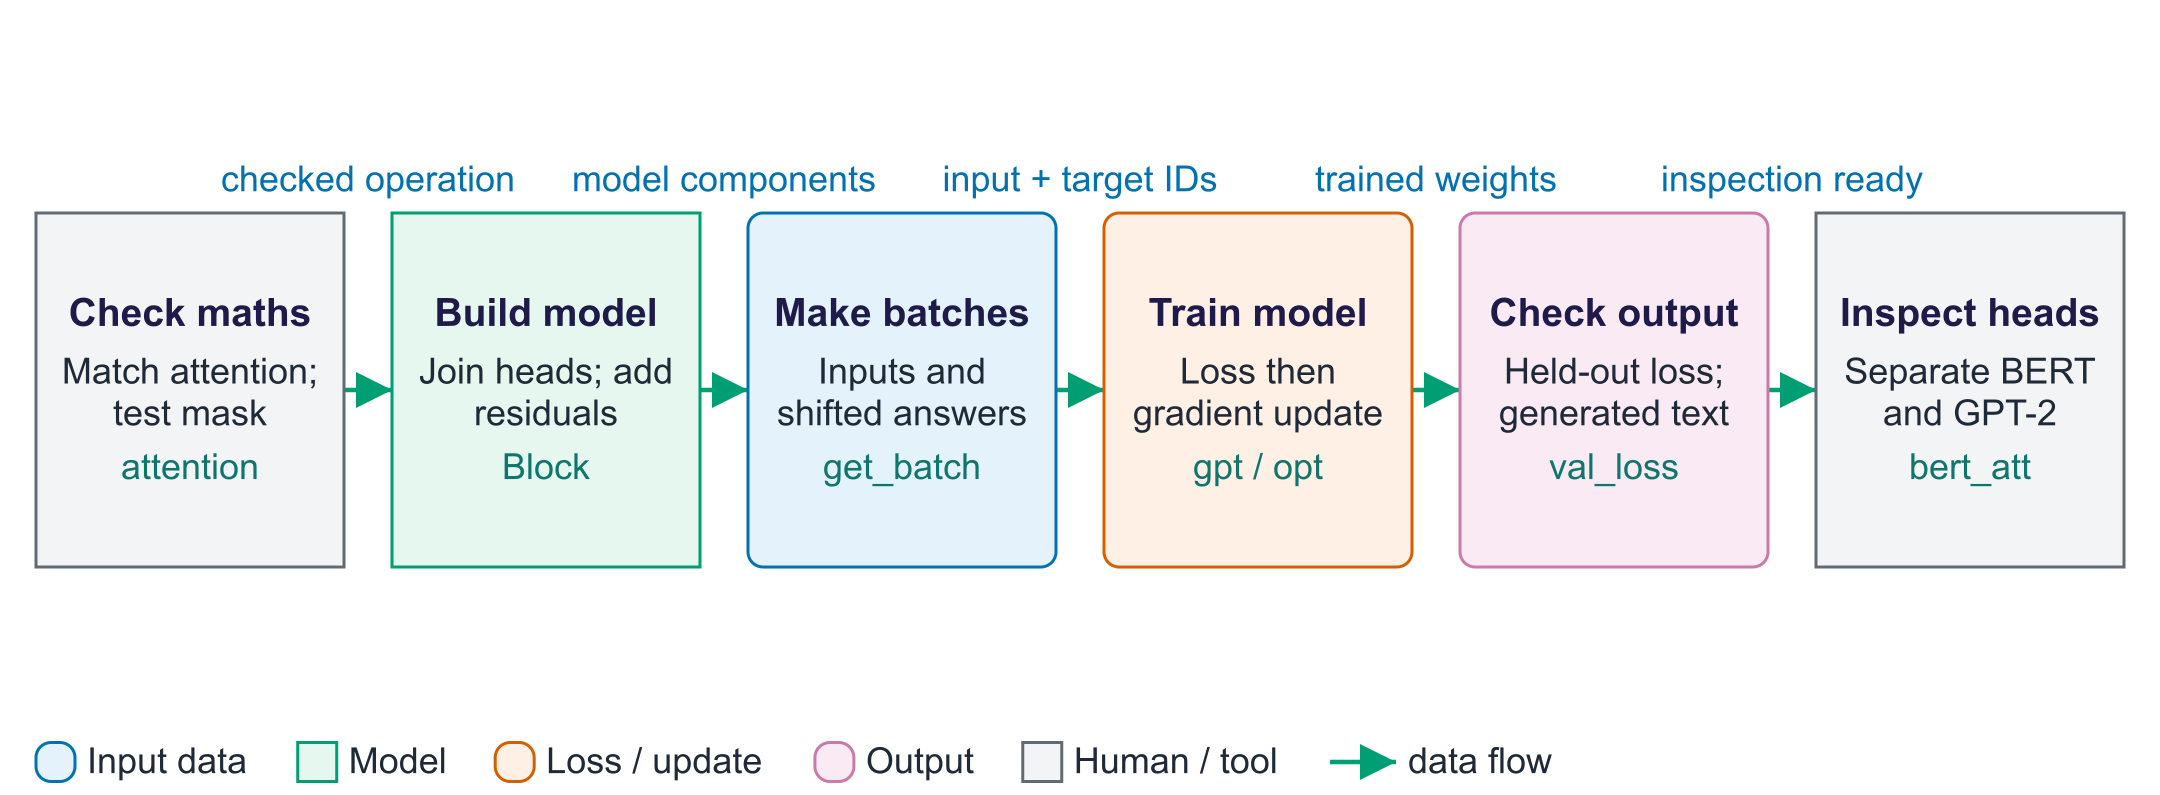

| Diagram operation | Code to find | What to inspect |
|---|---|---|
| Calculate attention | `attention`, `causal_mask` | Weights and forbidden future positions |
| Assemble a block | `MultiHeadAttention`, `Block` | Batch, head, position and feature axes |
| Prepare examples | `get_batch` | Targets shifted one character ahead |
| Predict and learn | `CharGPT`, `opt` | Prediction error and parameter updates |
| Check and generate | `val_loss`, `CharGPT.generate` | Held-out error and sampled characters |
| Inspect pretrained models | `bert_att`, `att` | Attention routing in separate models |

Use this routine throughout: **read → predict → run → change → check**.
Read the short cell guide. Predict a shape or behaviour before running.
Complete each TODO. Run its checks. Change one setting and explain the result.
An **assertion** stops the notebook when an expected property is false.

### Install the libraries

**What/why:** install PyTorch for numerical learning, Transformers for
pretrained models, and NumPy/Matplotlib for measurements and plots.
**Predict:** this cell prepares tools; it does not train a model.
**Expected output:** installation messages, or no output if already installed.
**Check:** the imports in the next cell must succeed.

In [ ]:
%pip install -q torch transformers matplotlib numpy

### Select the available hardware

**What/why:** import the tools, set a random seed and choose GPU or CPU.
A seed makes this run easier to repeat; different hardware can still differ.
**Predict:** which device will your runtime report?
**Expected output:** `device: cuda` for a supported GPU, otherwise `device: cpu`.
**Change/check:** GPU availability changes runtime, not the attention rule.

In [ ]:
import math
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
SEED = 0
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("run:", "smoke execution check" if SMOKE else "teaching experiment")

## Part 1: Mix information with attention

Think of each position asking: "Which earlier information helps me?"
A **query**, Q, describes what it seeks. A **key**, K, describes what a
position offers. A **value**, V, carries the information to mix.

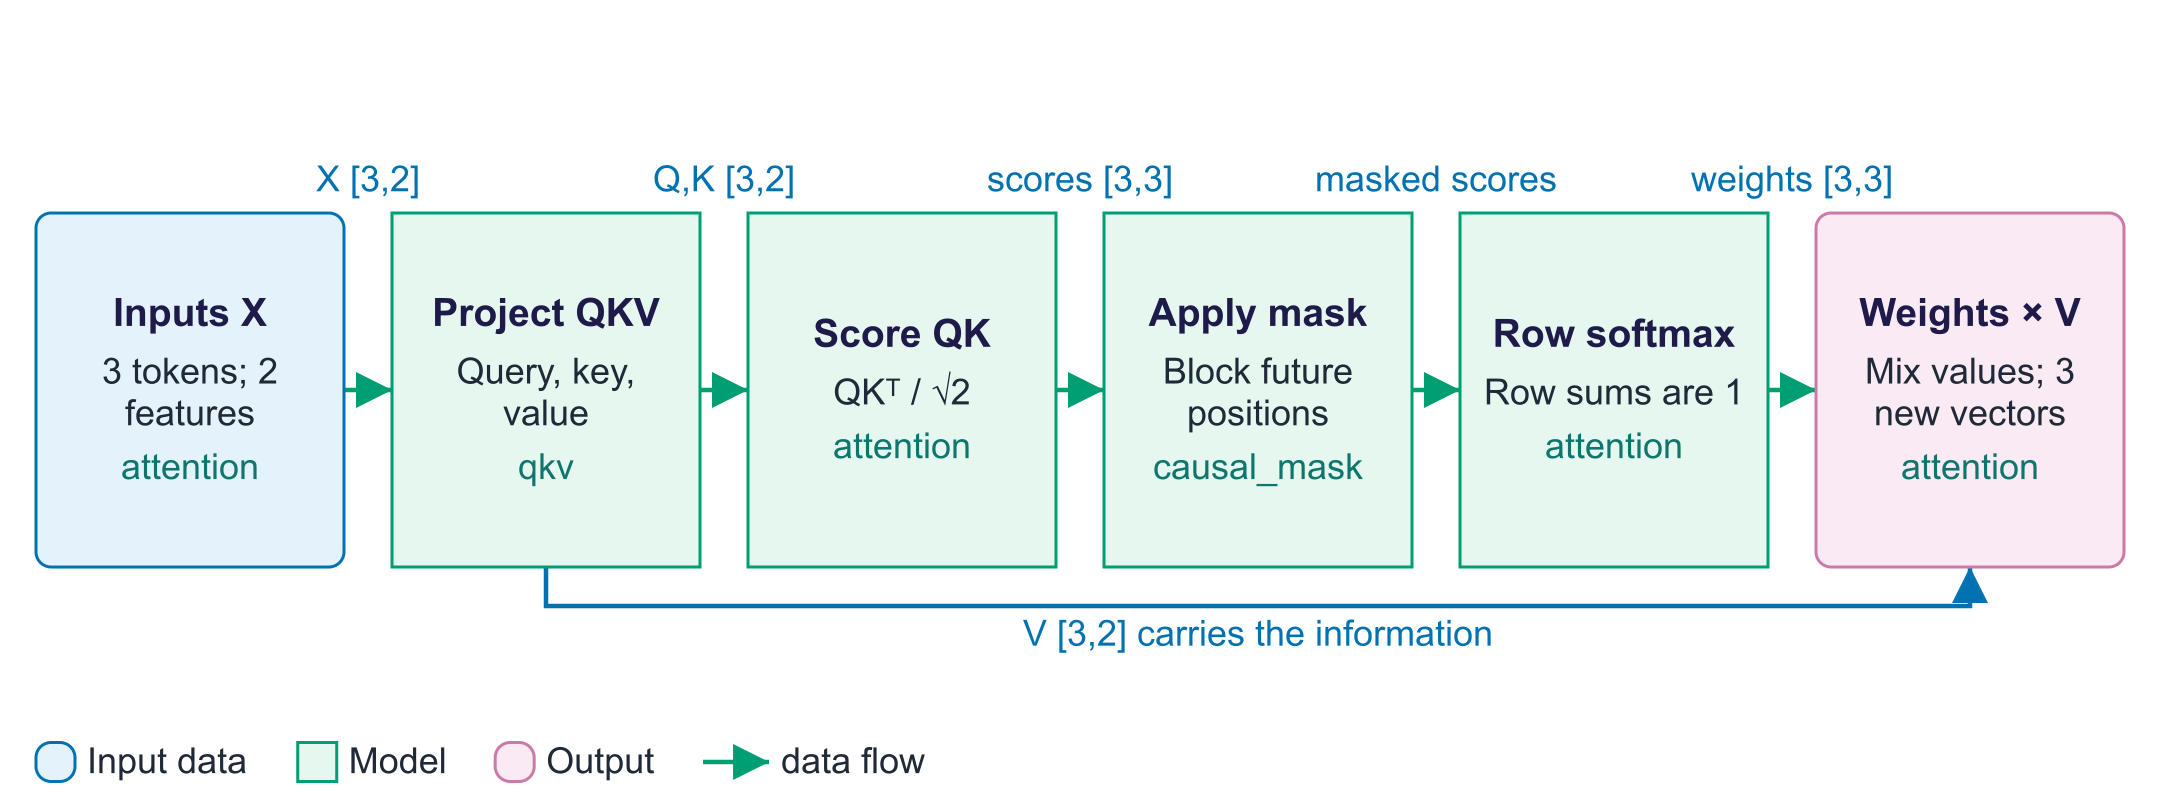

Read the equation as four operations: compare, scale, normalise, mix.
**Softmax** turns scores into positive weights that sum to one in each row.

$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Q and K are query/key arrays. V is the value array. `d_k` counts features
in each query/key. The superscript T means transpose: swap the final axes.
For three positions, the score and weight tables are `[3, 3]`.
Rows ask questions; columns supply information. They are not word meanings.

**TODO 1:** implement `attention(q, k, v, mask=None)`.
Q and K have shape `[..., n, d_k]` here. V has one row per input position.
A boolean mask uses `True` for **not allowed**; replace those scores with
negative infinity before softmax. Return the mixed values and their weights.
At least one key must remain allowed in each row.

**What/why:** calculate a tiny example, then compare your function with PyTorch.
**Predict:** how much weight will the last query give to each value?
**Expected output:** a `[3, 3]` weight table and a `[3, 2]` output table.
**Change/check:** change V. The weights should stay fixed; the mixture changes.

In [ ]:
def attention(q, k, v, mask=None):
    d_k = q.size(-1)
    pass  # TODO: write your code here


# These small arrays are a worked calculation, not trained model measurements.
Q = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
V = torch.tensor([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]])
out, w = attention(Q, Q, V)
print("weights:\n", w.numpy().round(3))
print("outputs:\n", out.numpy().round(3))
assert torch.allclose(w[2], torch.tensor([0.248, 0.248, 0.503]), atol=2e-3)
assert torch.allclose(w.sum(-1), torch.ones(3))

x = torch.randn(2, 4, 7, 16)  # [batch, heads, positions, features]
ref = F.scaled_dot_product_attention(x, x, x)
assert torch.allclose(attention(x, x, x)[0], ref, atol=1e-5)
print("PASS: attention matches the worked example and PyTorch")

### Why divide the scores by the square root of the feature count?

**What/why:** larger random vectors tend to produce more widely spread scores.
Very large scores can make softmax put almost all its weight on one value.
**Predict:** will the raw score spread grow as `d_k` increases?
**Expected output:** measured score spread and largest weights for three sizes.
**Change/check:** repeat with another seed. Individual rows vary; look for
the scale of the score spread, rather than a guaranteed ordering of weights.

In [ ]:
for d in (4, 64, 512):
    a, b = torch.randn(10000, d), torch.randn(10000, d)
    dots = (a * b).sum(-1)
    row = torch.randn(8, d) @ torch.randn(d)
    print(f"d_k={d:4d}: raw score std={dots.std():6.2f}; "
          f"largest weight: unscaled={row.softmax(0).max():.3f}, "
          f"scaled={(row / math.sqrt(d)).softmax(0).max():.3f}")

## Part 2: Hide the future and identify positions

A **causal mask** lets a position use itself and earlier positions.
It prevents training from revealing the character the model must predict.

**TODO 2:** complete `causal_mask(n)`. Return a boolean `[n, n]` table
with `True` above the diagonal: those columns are future positions.

**What/why:** build the mask and check that future positions receive zero weight.
**Predict:** how many positions may the first row use?
**Expected output:** a lower triangular weight table, followed by a PASS message.
**Change/check:** try `n=3` and print the mask before the weights.

In [ ]:
def causal_mask(n, device="cpu"):
    pass  # TODO: write your code here


m = causal_mask(5)
_, w = attention(torch.randn(5, 8), torch.randn(5, 8), torch.randn(5, 8), mask=m)
print(w.numpy().round(2))
assert torch.all(w[m] == 0), "future positions must have zero weight"
ref = F.scaled_dot_product_attention(x, x, x, is_causal=True)
assert torch.allclose(attention(x, x, x, mask=causal_mask(7))[0], ref, atol=1e-5)
print("PASS: causal masking matches PyTorch")

### What happens if we shuffle positions?

**What/why:** use attention without a mask or positional information.
Reorder the input vectors, then compare the reordered outputs.
**Predict:** will the model detect the new order?
**Expected output:** `True`: shuffling inputs simply shuffles these outputs.
**Change/check:** add different position vectors to the inputs and repeat.
Keep the position vectors fixed while shuffling the token vectors.

In [ ]:
tokens = torch.randn(6, 16)
perm = torch.randperm(6)
out1, _ = attention(tokens, tokens, tokens)
out2, _ = attention(tokens[perm], tokens[perm], tokens[perm])
same = torch.allclose(out1[perm], out2, atol=1e-6)
print("shuffled inputs produce shuffled outputs:", same)
assert same

**Question 1.** What did the shuffle show? Name two ways to add position information.

*✍️ Write your answer here.*

## Part 3: Combine heads and build a transformer block

An **attention head** learns one set of queries, keys and values.
Several heads mix information in parallel; their outputs are combined.
They are not guaranteed to learn separate human named concepts.

**TODO 3:** project to Q, K and V; split their features into heads; apply
attention; merge heads; apply the output projection.
For `[2, 10, 32]` and four heads, each head has eight features.
The attention arrays use `[2, 4, 10, 8]`; the final output is `[2, 10, 32]`.

A **residual connection** adds a block's input back to its output.
**Layer normalisation** adjusts the scale within each position's feature vector.
The **feed-forward network**, called `mlp` here, processes each position
separately with shared weights. `GELU` is its nonlinear activation.
**Dropout** randomly removes some contributions during training.
**Pre-norm** means normalisation happens before attention and the network.

**What/why:** assemble a block and verify its dimensions and causal behaviour.
**Predict:** can changing positions 7–9 change outputs at positions 0–6?
**Expected output:** a PASS message for both shape and causality checks.
**Change/check:** try eight heads with 32 features. Each head then has four features.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        b, n, d = x.shape  # [batch, positions, model features]
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        out = v  # TODO 3: split heads, attend, merge heads
        return self.proj(out)


class Block(nn.Module):
    """Normalise, attend and add; then normalise, process and add."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.GELU(),
            nn.Linear(4 * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, mask):
        # Attention exchanges information; the feed-forward network acts per position.
        x = x + self.attn(self.ln1(x), mask)
        return x + self.mlp(self.ln2(x))


mha = MultiHeadAttention(32, 4)
y = mha(torch.randn(2, 10, 32), causal_mask(10))
assert y.shape == (2, 10, 32)
xa = torch.randn(1, 10, 32)
xb = xa.clone()
xb[0, 7:] = torch.randn(3, 32)
ya, yb = mha(xa, causal_mask(10)), mha(xb, causal_mask(10))
assert torch.allclose(ya[0, :7], yb[0, :7], atol=1e-5), "earlier outputs used future inputs"
print("PASS: multi-head attention has the right shape and hides the future")

## Part 4: Train a small next-character model

### Prepare the training pairs

**What/why:** download Tiny Shakespeare, give each character an ID, and
reserve the final 10% of the text for validation: checking text not used to train.
`get_batch` selects a **batch**, a small collection of training examples.
Input `ROME` and target `OMEO` illustrate the one-character shift.

**Predict:** should inputs and targets have the same shape?
**Expected output:** dataset source, character count, vocabulary size and batch shape.
**Change/check:** decode one batch row and its target. Check the one-character shift.

**Offline fallback:** repeated lines allow the code to run without a download.
The training and validation portions then repeat the same lines.
A low validation error on that fallback cannot demonstrate generalisation
to unfamiliar writing. The notebook labels which dataset you actually used.

In [ ]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_SOURCE = "Tiny Shakespeare download"
try:
    with urllib.request.urlopen(URL, timeout=20) as response:
        text = response.read().decode("utf-8")
except Exception as error:
    print("download failed; using repeated built-in text:", error)
    DATA_SOURCE = "repeated offline fallback; validation is not independent content"
    text = ("ROMEO:\nBut soft, what light through yonder window breaks?\n"
            "It is the east, and Juliet is the sun.\n" * 300)
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
VOCAB = len(chars)

# Smaller settings preserve the operations while making CPU and smoke runs practical.
if SMOKE:
    CTX, BATCH_SIZE, D_MODEL, N_HEADS, N_LAYERS, default_steps = 32, 4, 48, 4, 2, 4
elif DEVICE == "cuda":
    CTX, BATCH_SIZE, D_MODEL, N_HEADS, N_LAYERS, default_steps = 128, 64, 192, 6, 4, 3000
else:
    CTX, BATCH_SIZE, D_MODEL, N_HEADS, N_LAYERS, default_steps = 64, 8, 96, 4, 2, 200
STEPS = int(os.environ.get("GENAI_TRAIN_STEPS", default_steps))
if STEPS < 1:
    raise ValueError("GENAI_TRAIN_STEPS must be at least 1")
VAL_BATCHES = 2 if SMOKE else (10 if DEVICE == "cuda" else 4)
print("dataset:", DATA_SOURCE)
print(f"{len(text):,} characters; {VOCAB} distinct characters")
print(f"context={CTX}, batch={BATCH_SIZE}, features={D_MODEL}, "
      f"heads={N_HEADS}, layers={N_LAYERS}, updates={STEPS}")


def get_batch(which, bs=None):
    bs = BATCH_SIZE if bs is None else bs
    d = train_data if which == "train" else val_data
    ix = torch.randint(len(d) - CTX, (bs,))
    xb = torch.stack([d[i:i + CTX] for i in ix])
    yb = torch.stack([d[i + 1:i + CTX + 1] for i in ix])
    return xb.to(DEVICE), yb.to(DEVICE)


example_x, example_y = get_batch("train", bs=1)
print("batch shapes:", tuple(example_x.shape), tuple(example_y.shape))
print("input: ", "".join(itos[i] for i in example_x[0].tolist()))
print("target:", "".join(itos[i] for i in example_y[0].tolist()))
assert torch.equal(example_x[:, 1:], example_y[:, :-1])

### Turn IDs into next-character scores

**What/why:** build `CharGPT`, our small decoder model. Add learned token
and position vectors, process transformer blocks, then score each character.
**Logits** are these unnormalised scores: `[batch, positions, vocabulary]`.
Softmax turns the final position's scores into next-character probabilities.
`generate` samples a character, appends it, and repeats with fixed weights.

**Predict:** which axis lists possible next characters?
**Expected output:** the measured parameter count and checked output shape.
**Change/check:** change the layer count before training, and compare parameter counts.

In [ ]:
class CharGPT(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS):
        super().__init__()
        self.tok = nn.Embedding(VOCAB, d_model)
        self.pos = nn.Embedding(CTX, d_model)  # learned absolute position vectors
        self.blocks = nn.ModuleList([Block(d_model, n_heads) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, VOCAB)

    def forward(self, idx):
        n = idx.size(1)
        x = self.tok(idx) + self.pos(torch.arange(n, device=idx.device))
        mask = causal_mask(n, idx.device)
        for blk in self.blocks:
            x = blk(x, mask)
        return self.head(self.ln(x))

    @torch.no_grad()
    def generate(self, idx, n_new, temperature=1.0):
        if temperature <= 0:
            raise ValueError("temperature must be positive")
        for _ in range(n_new):
            # Crop the context; only the last position scores the next character.
            logits = self(idx[:, -CTX:])[:, -1] / temperature
            next_id = torch.multinomial(logits.softmax(-1), 1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


gpt = CharGPT().to(DEVICE)
PARAMETERS = sum(p.numel() for p in gpt.parameters())
print(f"CharGPT: {PARAMETERS:,} learned parameters")
assert gpt(example_x).shape == (1, CTX, VOCAB)

### Measure error, then update the weights

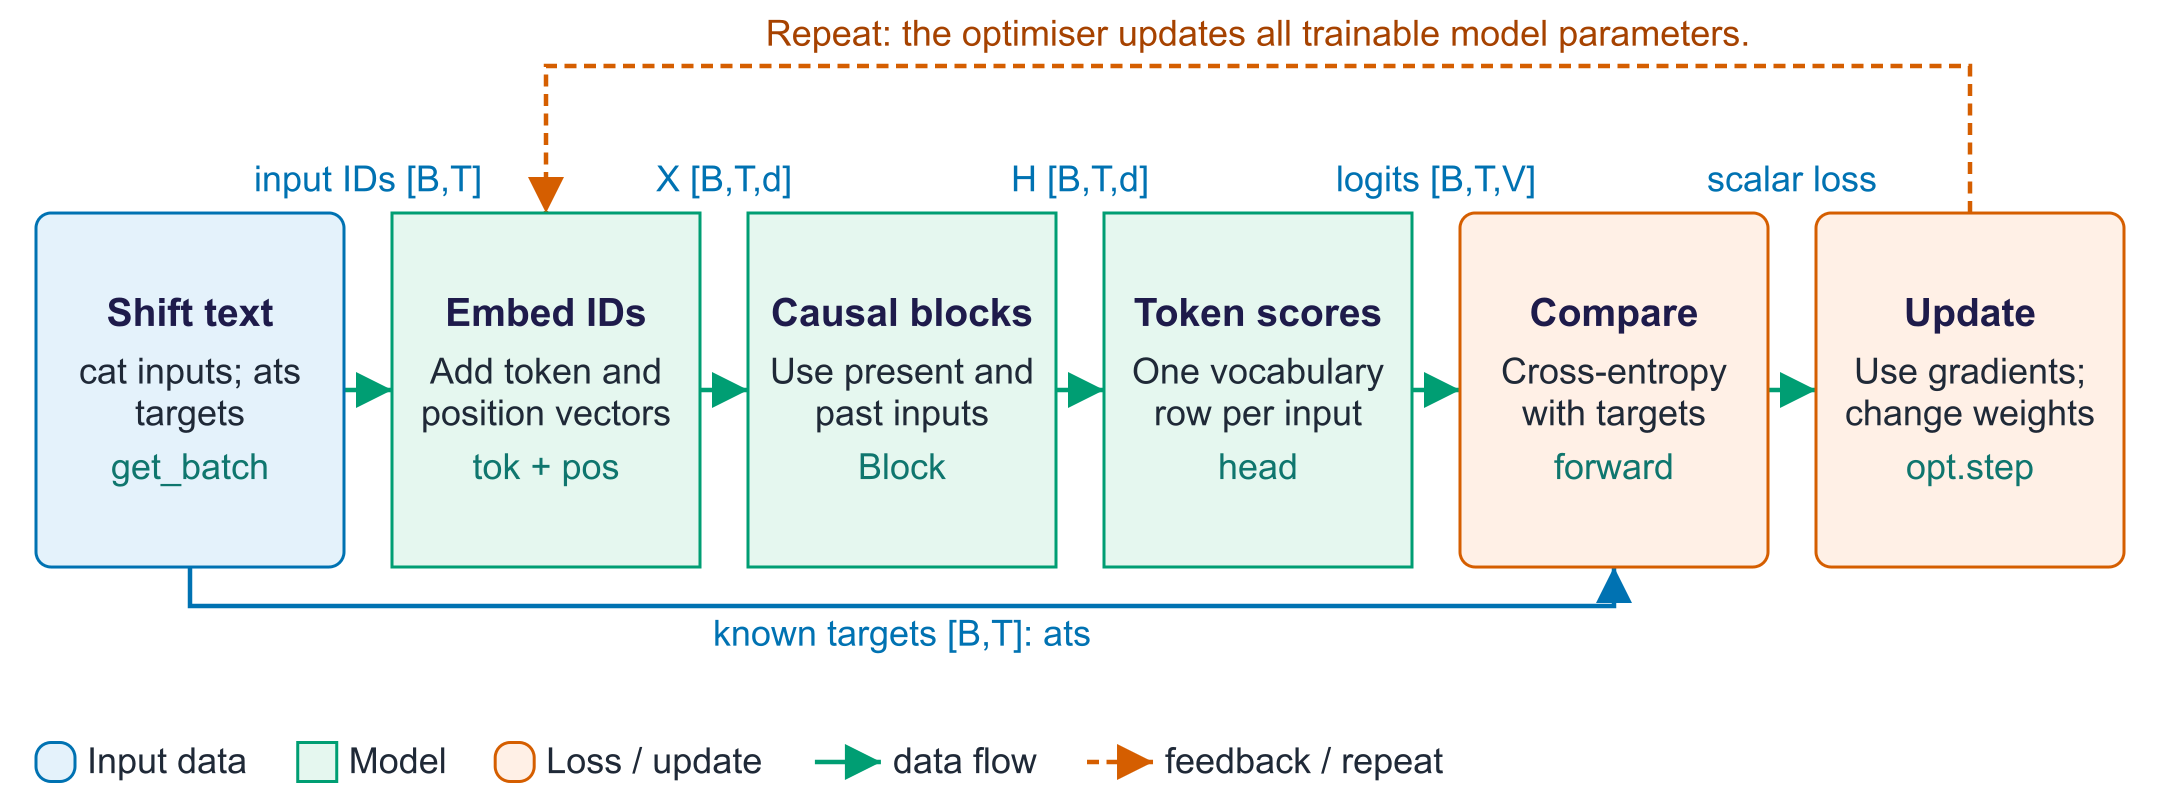

**Cross-entropy loss** penalises low probability for the correct next character.
Lower loss means better predictions on those examples. **Nats** are natural-log units.
A **gradient** describes how changing each parameter changes the loss.
`backward` computes gradients. The **optimiser**, AdamW, uses them to update weights.
Validation measures error without updating weights.

**What/why:** train the model and periodically measure validation loss.
`eval()` disables dropout for validation; `train()` enables it for learning.
**Predict:** what would loss near `log(VOCAB)` mean? Uniform guessing gives
every character the same probability.
**Expected output:** measured validation losses, elapsed seconds and a loss plot.
**Change/check:** compare your final loss with uniform guessing. Do not assume
the short CPU or smoke run will produce fluent text or a steadily falling curve.

In [ ]:
@torch.no_grad()
def val_loss(model, batches=VAL_BATCHES):
    was_training = model.training
    model.eval()
    losses = []
    for _ in range(batches):
        xb, yb = get_batch("val")
        loss = F.cross_entropy(model(xb).reshape(-1, VOCAB), yb.reshape(-1))
        losses.append(loss.item())
    model.train(was_training)
    return float(np.mean(losses))


def synchronize_device():
    # GPU operations are asynchronous; wait for completion before reading a timer.
    if DEVICE == "cuda":
        torch.cuda.synchronize()


opt = torch.optim.AdamW(gpt.parameters(), lr=1e-3)
gpt.train()
curve = []
synchronize_device()
t0 = time.perf_counter()
for step in range(STEPS + 1):
    if step % max(1, STEPS // 10) == 0 or step == STEPS:
        curve.append((step, val_loss(gpt)))
        print(f"step {step:5d}: validation loss {curve[-1][1]:.3f} "
              f"({time.perf_counter() - t0:.1f} seconds)")
    if step == STEPS:
        break
    xb, yb = get_batch("train")
    loss = F.cross_entropy(gpt(xb).reshape(-1, VOCAB), yb.reshape(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
synchronize_device()
TRAIN_SECONDS = time.perf_counter() - t0

c = np.array(curve)
plt.plot(c[:, 0], c[:, 1], marker="o", label="measured validation loss")
plt.axhline(math.log(VOCAB), ls="--", color="gray", label="uniform guessing")
plt.xlabel("parameter updates")
plt.ylabel("validation loss (nats per character)")
plt.title("Next-character prediction: validation error")
plt.legend()
plt.show()

### Convert the measured error to perplexity

**Perplexity** is `exp(average cross-entropy loss)` with natural logarithms.
It expresses uncertainty on the same prediction task. Uniform guessing over
`VOCAB` characters has perplexity `VOCAB`; lower is better on the same text.
**TODO 4:** compute perplexity from the final measured validation loss.

**What/why:** make the model's uncertainty easier to interpret.
**Predict:** what perplexity corresponds to loss `log(VOCAB)`?
**Expected output:** this run's measured perplexity and its uniform baseline.
**Change/check:** compare only runs with the same token unit, dataset and settings.

In [ ]:
final_loss = curve[-1][1]
perplexity = None  # TODO 4
print(f"validation perplexity={perplexity:.2f}; uniform baseline={VOCAB}")

### Generate one character at a time

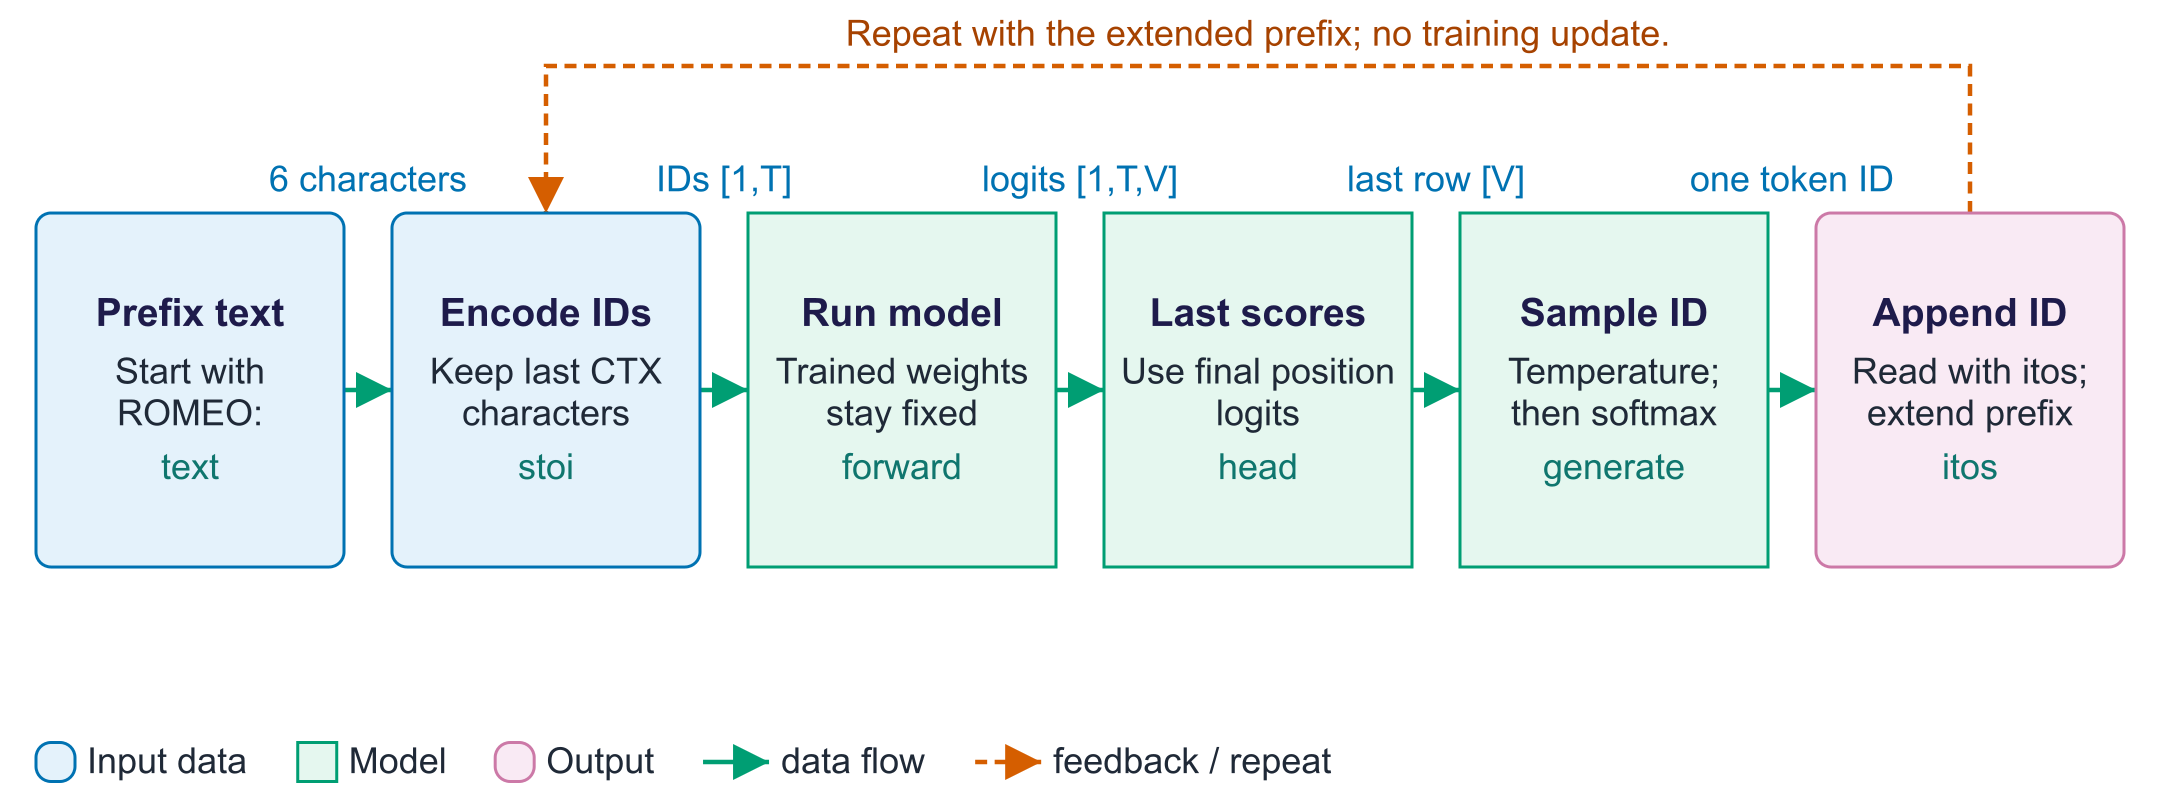

**Temperature** divides logits before sampling. Lower values concentrate
probability; higher values flatten it. It does not change the learned weights.
**Inference** means using learned weights to produce an output.

**What/why:** disable dropout, then sample three continuations from `ROMEO:`.
**Predict:** which temperature might produce the most varied characters?
**Expected output:** three actual samples. Early training can produce nonsense.
**Change/check:** keep the seed and prompt fixed; change temperature alone.
Inspect your own outputs before claiming any learned spelling or meaning.

In [ ]:
gpt.eval()  # No gradients alone would not disable training-time dropout.
prompt = torch.tensor([[stoi[ch] for ch in "ROMEO:\n" if ch in stoi]], device=DEVICE)
samples = {}
N_SAMPLE = 24 if SMOKE else (250 if DEVICE == "cuda" else 100)
for temperature in (0.5, 1.0, 1.5):
    torch.manual_seed(SEED)
    generated = gpt.generate(prompt, N_SAMPLE, temperature=temperature)
    sample = "".join(itos[i] for i in generated[0].tolist())
    samples[str(temperature)] = sample
    print(f"\n--- temperature {temperature} ---\n{sample}")

**Question 2.** Interpret your perplexity and samples. Why can you not compare
this number directly with a word-piece model's perplexity?

*✍️ Write your answer here.*

## Part 5: Inspect separate pretrained models

BERT is an **encoder**: each position may attend to the complete input.
GPT-2 is a **decoder**: a position may attend only to itself and its past.
These downloaded models are separate from the small model you just trained.
Their tokenizers can split words into smaller pieces, so a token can be part of a word.
A **pretrained** model already has learned weights before this lab.

### Read BERT's attention tables

**What/why:** load BERT and request its attention weights using the explicit
`eager` implementation, which returns the tables needed for inspection.
**Predict:** can BERT's `it` position use the later word `tired`?
**Expected output:** the measured layer and head counts for this saved model.
**Change/check:** inspect `toks` to see special tokens and word pieces.
The first use downloads model files; later runs may use the local cache.

In [ ]:
from transformers import AutoModel, AutoTokenizer

sentence = "The animal didn't cross the street because it was too tired."
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", attn_implementation="eager").eval()
enc = bert_tok(sentence, return_tensors="pt")
with torch.no_grad():
    bert_att = torch.stack(bert(**enc, output_attentions=True).attentions)[:, 0]
toks = bert_tok.convert_ids_to_tokens(enc["input_ids"][0])
i_it, i_animal, i_street = toks.index("it"), toks.index("animal"), toks.index("street")
print(f"BERT: {bert_att.shape[0]} layers, {bert_att.shape[1]} heads per layer")
print("tokens:", toks)

### Find and inspect one selected head

**TODO 5:** find the layer/head with the largest weight from `it` to `animal`.
Plot its full table, then compare that weight across all heads.

**What/why:** inspect information routing, including the selection we made.
**Predict:** will every head give `animal` a large weight?
**Expected output:** the selected head, a heatmap and a histogram of measured weights.
Rows are query positions; columns are key/value positions.
**Change/check:** inspect a typical head as well as the largest one.

In [ ]:
layer, head = 0, 0  # TODO 5
print(f"layer {layer + 1}, head {head + 1}: "
      f"it -> animal={bert_att[layer, head, i_it, i_animal]:.3f}; "
      f"it -> street={bert_att[layer, head, i_it, i_street]:.3f}")
plt.figure(figsize=(8, 7))
plt.imshow(bert_att[layer, head].numpy(), cmap="Purples", vmin=0, vmax=1)
plt.xticks(range(len(toks)), toks, rotation=70)
plt.yticks(range(len(toks)), toks)
plt.xlabel("key/value position: information source")
plt.ylabel("query position: information recipient")
plt.title(f"Selected BERT layer {layer + 1}, head {head + 1}")
plt.colorbar(label="attention weight")
plt.tight_layout()
plt.show()

plt.hist(bert_att[:, :, i_it, i_animal].flatten().numpy(), bins=30)
plt.xlabel("attention weight: it -> animal")
plt.ylabel("number of heads")
plt.title(f"Across all {bert_att.shape[0] * bert_att.shape[1]} BERT heads")
plt.tight_layout()
plt.show()

### Test GPT-2's causal boundary

**What/why:** compare `tired` with `wide` in an otherwise identical sentence.
Both words appear **after** `it`. Its attention row cannot read either word.
**Predict:** should the row for `it` change?
**Expected output:** measured mean weights and a check that the row is unchanged.
**Change/check:** inspect a position after the adjective to study its effect.
This experiment checks causality; it does not test pronoun resolution using
the complete sentence.

In [ ]:
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", attn_implementation="eager").eval()
it_rows = []
for s in (sentence, sentence.replace("tired", "wide")):
    ids = gpt2_tok(s, return_tensors="pt")
    with torch.no_grad():
        att = torch.stack(gpt2(**ids, output_attentions=True).attentions)[:, 0]
    gt = gpt2_tok.convert_ids_to_tokens(ids["input_ids"][0])
    j_it = [k for k, token in enumerate(gt) if token.lstrip("Ġ") == "it"][0]
    j_an = [k for k, token in enumerate(gt) if token.lstrip("Ġ") == "animal"][0]
    j_st = [k for k, token in enumerate(gt) if token.lstrip("Ġ") == "street"][0]
    it_rows.append(att[:, :, j_it, :j_it + 1].clone())
    avg = att[:, :, j_it].mean(dim=(0, 1))
    print(f"{s[-12:]!r}: mean it -> animal={avg[j_an]:.3f}; "
          f"it -> street={avg[j_st]:.3f}")
assert torch.allclose(it_rows[0], it_rows[1], atol=1e-6)
print("PASS: a later adjective does not change attention at 'it'")

**Question 3.** Does the selected attention plot explain a pronoun decision?
Give two reasons for caution using the histogram and the GPT-2 comparison.

*✍️ Write your answer here.*

## Part 6: Optional key/value-cache timing experiment

A **KV cache** stores earlier keys and values during generation.
New tokens can reuse them, instead of recalculating the whole prefix.
It consumes memory and usually saves repeated computation. It does not
extend the model's context window or replace the learned weights.

**What/why:** time GPT-2 with caching enabled and disabled using the same
prompt, token count, device and greedy selection rule.
Warm both paths first. Synchronise CUDA before and after each timer.
**Predict:** which path should benefit as the prefix grows?
**Expected output:** measured timings and their measured ratio, not a guaranteed speed-up.
**Change/check:** vary the new-token count. Short runs and CPU measurements
can have noisy timings. The displayed ratio applies only to this configuration.

In [ ]:
from transformers import AutoModelForCausalLM

# Free inspection models before loading another GPT-2 copy.
del bert, gpt2
lm = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()
ids = gpt2_tok("Once upon a time", return_tensors="pt").to(DEVICE)
n_new = 4 if SMOKE else (200 if DEVICE == "cuda" else 20)
repeats = 1 if SMOKE else 3
kv_timings = {}


@torch.no_grad()
def run_generation(use_cache, count):
    return lm.generate(
        **ids, max_new_tokens=count, min_new_tokens=count,
        do_sample=False, use_cache=use_cache, pad_token_id=gpt2_tok.eos_token_id,
    )


# Warm-up is outside the measured interval for each configuration.
for use_cache in (True, False):
    run_generation(use_cache, 2)
synchronize_device()
for use_cache in (True, False):
    timings = []
    for _ in range(repeats):
        synchronize_device()
        timer_start = time.perf_counter()
        output_ids = run_generation(use_cache, n_new)
        synchronize_device()
        timings.append(time.perf_counter() - timer_start)
        assert output_ids.shape[1] == ids["input_ids"].shape[1] + n_new
    kv_timings[str(use_cache)] = timings
    print(f"use_cache={use_cache}: median={np.median(timings):.3f} seconds "
          f"for {n_new} new tokens ({repeats} measured run(s))")
cache_ratio = float(np.median(kv_timings["False"]) / np.median(kv_timings["True"]))
print(f"measured uncached/cached time ratio: {cache_ratio:.2f}")

## Check your work before leaving

| Check | Your observed result |
|---|---|
| Attention agrees with PyTorch | |
| Future weights are zero | |
| Multi-head shape and causal checks pass | |
| Final validation loss and perplexity | |
| Dataset source and generalisation limitation | |
| A real sample at each temperature | |
| How representative was the selected BERT head? | |
| Measured cache timings and ratio | |

**Recap:** queries compare with keys; weights mix values. Positions and the
causal mask serve different purposes. Training updates weights using known
targets. Generation keeps weights fixed and repeats next-token prediction.
Attention plots show routing; a convincing explanation needs stronger evidence.

**Before next week:** watch Karpathy's *Intro to Large Language Models*
and skim Tunstall et al., Chapter 1. Explain one generated fragment using
token IDs, attention, the causal mask and sampling.

## What we learned: transformers

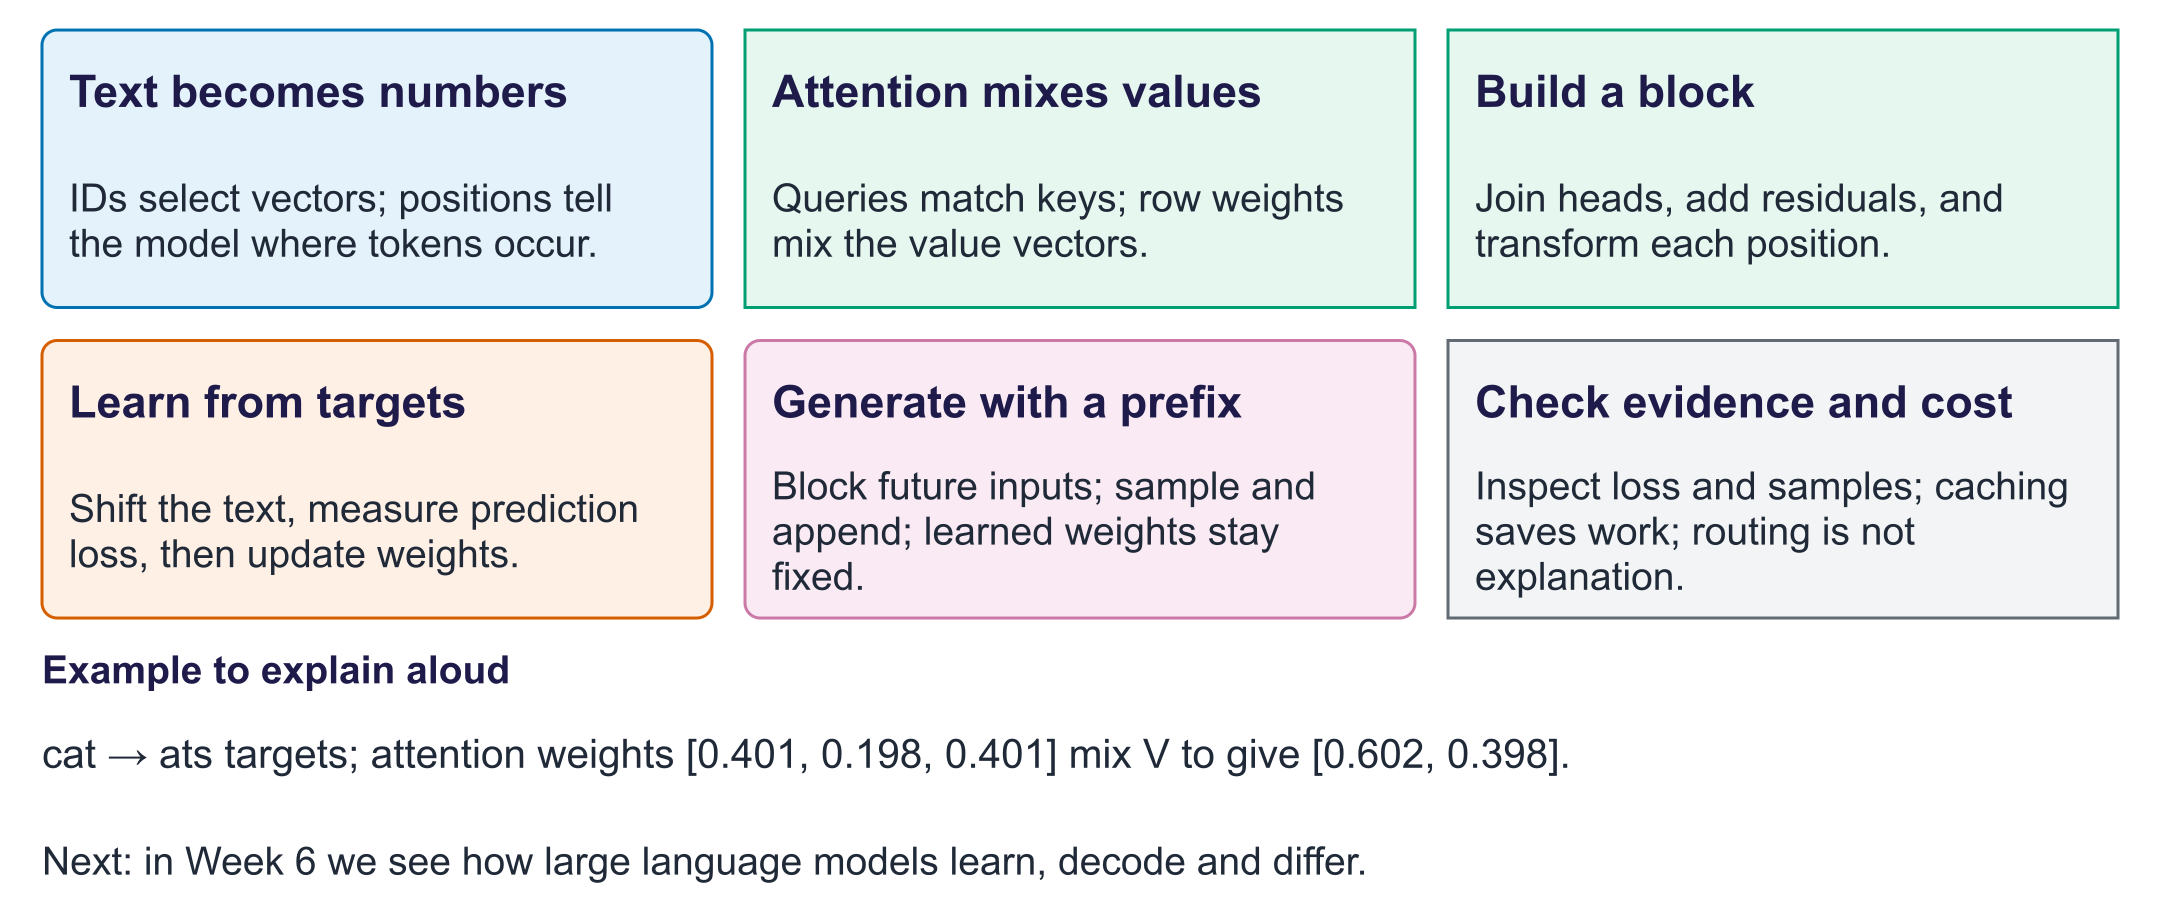

cat → ats targets; attention weights [0.401, 0.198, 0.401] mix V to give [0.602, 0.398].

**Explain without looking:** What changes during training, and what changes during generation?